
[Domain A] Fitting forest on labeled points...
[Domain A] OOB classification acc.: 0.9062
[Domain A] Computing FoSTA kernel (full NxN)...
[Domain A] Shapes: prox=(800, 800)

[Domain B] Fitting forest on labeled points...
[Domain B] OOB classification acc.: 0.9280
[Domain B] Computing FoSTA kernel (full NxN)...
[Domain B] Shapes: prox=(1000, 1000)
[Domain A] Semantic row sums before prior correction and l2 normalization: min=4.190780, mean=17.895194, max=42.731832
[Domain B] Semantic row sums before prior correction and l2 normalization: min=4.888822, mean=16.544697, max=39.634475
[FoSTA] Coupling shared-label points only: A=800/800, B=800/1000
Optimized rank-annealing schedule: [800]
HiRef: Aligning A(800) and B(800). Target square size: 800
Optimized rank-annealing schedule: [800]

JOINT AFFINITY BLOCK STATISTICS
------------------------------

Within-domain A (W1):
  Total mass : 14316.1543
  Row sums   : min=4.1908, max=42.7318, mean=17.8952
  Col sums   : min=4.1908, max=42.7318, 

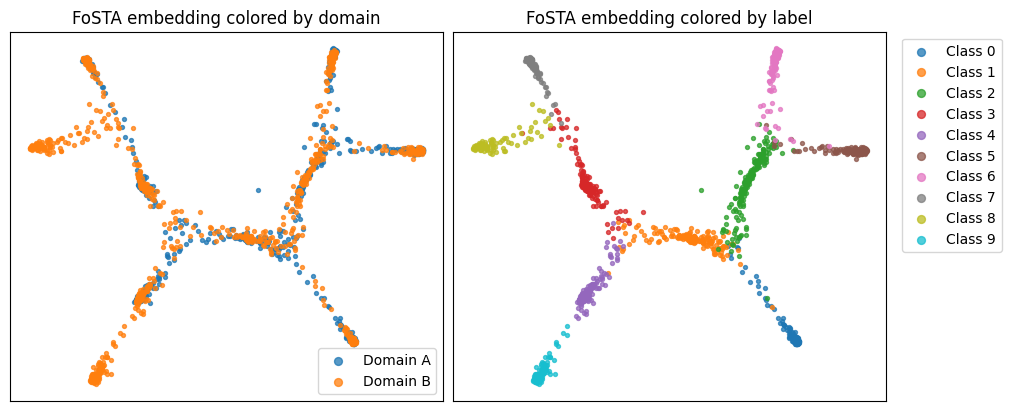

In [2]:
# Fit FoSTA and plot the aligned tree domains

import sys, pathlib
sys.path.insert(0, str(next(p for p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents) if (p/"src").is_dir())))

import numpy as np
import matplotlib.pyplot as plt
from src.fosta import FoSTA
from utils.tree_utils import gen_tree

# ---------------------------------------------------------------------
# Generate two tree-like domains with partial label overlap
# ---------------------------------------------------------------------
X_a, y_a, _ = gen_tree(
    n_branch=8,
    n_child=2,
    n_dim_per_branch=4,
    branch_length=100,
    seed=1,
    sigma=4,
    merged_branch=False,
)

X_b, y_b, _ = gen_tree(
    n_branch=10,  # one extra class/topological branch in B
    n_child=2,
    n_dim_per_branch=4,
    branch_length=100,
    seed=2,
    sigma=4,
    merged_branch=False,
)

# ---------------------------------------------------------------------
# Fit FoSTA
# ---------------------------------------------------------------------
fosta = FoSTA(
    n_estimators=200,
    random_state=0,
    verbose=1,
    ot_solver="hiref",
    embedder="PHATE",
    n_components=2,
)

Z = fosta.fit_transform(X_a, X_b, y_a, y_b)

# ---------------------------------------------------------------------
# Plot by domain and by label
# ---------------------------------------------------------------------
n_a = X_a.shape[0]
domain = np.array(["A"] * n_a + ["B"] * X_b.shape[0])
labels = np.concatenate([y_a, y_b])

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# Domain plot
for dom in ["A", "B"]:
    idx = domain == dom
    axes[0].scatter(
        Z[idx, 0],
        Z[idx, 1],
        s=8,
        alpha=0.75,
        label=f"Domain {dom}",
    )

axes[0].set_title("FoSTA embedding colored by domain")
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].legend(frameon=True, markerscale=2)

# Label plot
for lab in np.unique(labels):
    idx = labels == lab
    axes[1].scatter(
        Z[idx, 0],
        Z[idx, 1],
        s=8,
        alpha=0.75,
        label=f"Class {lab}",
    )

axes[1].set_title("FoSTA embedding colored by label")
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].legend(frameon=True, markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()